In [6]:
import torch.nn as nn
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

In [8]:
# build vocabulary of characters and mappings to/from integers
words = open("../names.txt", "r").read().splitlines()
words[:8]
len(words)

# build vocabulary of characters and mappings to/from integers
chars = sorted(list(set("".join(words))))
stoi = {s: i + 1 for i, s in enumerate(chars)}
stoi["."] = 0
itos = {i: s for s, i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)
words = open("../names.txt", "r").read().splitlines()
words[:8]
len(words)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


32033

In [9]:
# Build dataset
block_size = (
    3  # context length: how many characters do we take to predict the next one?
)


def build_dataset(words):
    X, Y = [], []

    for w in words:
        context = [0] * block_size
        for ch in w + ".":
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]  # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

In [10]:
import random

random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])  # 80%
Xval, Yval = build_dataset(words[n1:n2])  # 10%
Xte, Yte = build_dataset(words[n2:])  # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [3]:
device = torch.device("mps")
device

device(type='mps')

# Custom Implementation

In [ ]:
class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []


class Linear:
    def __init__(self, f_in, f_out, bias=True) -> None:
        self.weight = torch.randn((f_in, f_out))
        self.bias = torch.zeros(f_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight

        if self.bias:
            self.out += self.bias

        return self.out

    def parameters(self):
        return [self.weight] + ([self.bias] if self.bias is not None else [])


# state in this layer can be harmful, need mean & variance to stabilize
class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1) -> None:
        self.eps = eps
        self.momentum = momentum
        self.training = True

        # parameters (train with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.ones(dim)

        # buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        if self.training:
            if x.ndim == 2:
                dim = 0
            elif x.ndim == 3:
                dim = (0, 1)
            x_mean = x.mean(dim, keepdim=True)  # batch mean
            x_var = x.var(dim, keepdim=True)  # batch var
        else:
            x_mean = self.running_mean
            x_var = self.running_var

        x_hat = (x - x_mean) / torch.sqrt(
            x_var + self.eps
        )  # normalize to unit variance
        self.out = self.gamma * x_hat + self.beta

        # update buffers
        if self.training:
            with torch.inference_mode():
                self.running_mean = (
                    1 - self.momentum
                ) * self.running_mean + self.momentum * x_mean
                self.running_var = (
                    1 - self.momentum
                ) * self.running_var + self.momentum * x_var

        return self.out

    def parameters(self):
        return [self.gamma, self.beta]


class Embedding:
    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn([num_embeddings, embedding_dim])

    def __call__(self, IX):
        return self.weight[IX]

    def parameters(self):
        return [self.weight]


class FlattenConsecutive:
    def __init__(self, n):
        self.n = n

    def __call__(self, x):
        B, T, C = x.shape
        x = x.view(B, T // self.n, C * self.n)

        if x.shape[1] == 1:
            x = x.squeeze(1)

        return x


In [ ]:
model = Sequential(
    Embedding(vocab_size, n_embd),
    FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh()
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh()
    FlattenConsecutive(2), Linear(n_hiden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size)
)

# PyTorch Implementation

In [ ]:
Linear(n_embd * block_size, n_hidden, bias=False),
    BatchNorm1d(n_hidden),
    Tanh(),
    Linear(n_hidden, vocab_size)

In [79]:
class SimpleModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Embedding(vocab_size, n_embd),
            nn.Flatten(),
            nn.Linear(n_embd * block_size, n_hidden, bias=False),
            nn.BatchNorm1d(n_hidden),
            nn.Tanh(),
            nn.Linear(n_hidden, vocab_size),
        )

    def forward(self, x):
        return self.model(x)


model = SimpleModel()
print(sum(p.numel() for p in model.parameters()))

12097


In [ ]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10000)

In [83]:
max_steps = 200000
batch_size = 32
loss_i = []
model = model.to(device)

for i in tqdm(range(max_steps)):
    # minibatch construct
    idx = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[idx], Ytr[idx]

    Xb = Xb.to(device)
    Yb = Yb.to(device)

    # forward pass
    x = Xb
    x = model(x)
    loss = F.cross_entropy(x, Yb)  # loss func
    loss.backward()

    # update grad
    optimizer.zero_grad()

    optimizer.step()
    scheduler.step()

    # track stas
    if i % 10000 == 0:
        print(f"{i:7d} / {max_steps:7d}: {loss.item():4f}")
    loss_i.append(loss.log10().item())

  0%|          | 0/200000 [00:00<?, ?it/s]

      0 /  200000: 3.456643
  10000 /  200000: 3.329072
  20000 /  200000: 3.549162
  30000 /  200000: 3.349794
  40000 /  200000: 3.358470
  50000 /  200000: 3.482739
  60000 /  200000: 3.300660
  70000 /  200000: 3.296992
  80000 /  200000: 3.283736
  90000 /  200000: 3.396517
 100000 /  200000: 3.288505
 110000 /  200000: 3.364642
 120000 /  200000: 3.415894
 130000 /  200000: 3.368240
 140000 /  200000: 3.392932
 150000 /  200000: 3.430082
 160000 /  200000: 3.396688
 170000 /  200000: 3.327551
 180000 /  200000: 3.321315
 190000 /  200000: 3.343976


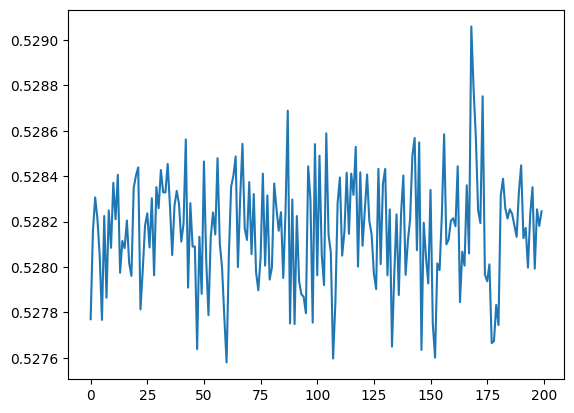

In [84]:
# take mean along row for better plotting
plt.plot(torch.tensor(loss_i).view(-1, 1000).mean(1))

In [ ]:
# evlauate loss
@torch.no_grad()
def split_loss(split):
    x, y = {"train": (Xtr, Ytr), "val": (Xval, Yval), "test": (Xte, Yte)}[split]
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())


split_loss("train")
split_loss("val")

train 3.37424373626709


RuntimeError: Placeholder storage has not been allocated on MPS device!

In [ ]:
# sample from model
with torch.inference_mode():
    for _ in range(1):
        out = []
        context = [0] * block_size

        while True:
            emb = C[torch.tensor([context])]
            x = emb.view(emb.shape[0], -1)

            model.eval()
            logits = model(x)
            probs = F.softmax(logits, dim=1)

            idx = torch.multinomial(probs, num_samples=1).item()
            context = context[1:] + [idx]  # shift context
            out.append(idx)

            if idx == 0:
                break

        print("".join(itos[i] for i in out))  # decode and print the generated word

igphentmthnlurhkf.
